Import necessary libraries

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
import urllib.request, ssl

Step 1: Helper Functions

In [2]:
def gdrive_to_direct_url(share_url):
    """Convert Google Drive shareable link to direct download link"""
    file_id = share_url.split("/d/")[1].split("/")[0]
    return f"https://drive.google.com/uc?export=download&id={file_id}"

def download_image(url):
    """Download and decode image from URL"""
    ctx = ssl._create_unverified_context()
    resp = urllib.request.urlopen(url, context=ctx)
    image_np = np.asarray(bytearray(resp.read()), dtype=np.uint8)
    return cv2.imdecode(image_np, cv2.IMREAD_COLOR)

def sharpen_image(image):
    """Apply a simple sharpening kernel to enhance edges"""
    kernel = np.array([[0, -1, 0],
                       [-1, 5,-1],
                       [0, -1, 0]])
    return cv2.filter2D(image, -1, kernel)

def compute_sift_descriptors(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    sift = cv2.SIFT_create()
    keypoints, descriptors = sift.detectAndCompute(gray, None)
    return keypoints, descriptors

def build_vocabulary(descriptor_list, k):
    all_descriptors = np.vstack(descriptor_list)
    kmeans = KMeans(n_clusters=k, random_state=42).fit(all_descriptors)
    return kmeans

def compute_bovw(descriptors, kmeans):
    words = kmeans.predict(descriptors)
    hist, _ = np.histogram(words, bins=np.arange(kmeans.n_clusters + 1))
    hist = hist.astype(float) / np.linalg.norm(hist)
    return hist

def compute_vlad(descriptors, kmeans):
    K = kmeans.n_clusters
    vocab = kmeans.cluster_centers_
    assignments = kmeans.predict(descriptors)
    vlad = np.zeros((K, descriptors.shape[1]))
    for i, a in enumerate(assignments):
        vlad[a] += descriptors[i] - vocab[a]
    vlad = vlad.flatten()
    vlad = vlad / np.linalg.norm(vlad)
    return vlad

def retrieve_images(query_desc, db_descs, top_k=3):
    sims = cosine_similarity([query_desc], db_descs)[0]
    return np.argsort(sims)[::-1][:top_k], sims

Step 2: Image URLs

In [3]:
image_urls = [
    ("Query",  "https://drive.google.com/file/d/1JchYFkCy8VSTtub2zuA5j99uU67PaN4W/view?usp=sharing"),
    ("Scene1", "https://drive.google.com/file/d/1M9kXYVBXa5zS9G2D3RWZOqQi1VwYdj1T/view?usp=sharing"),
    ("Scene2", "https://drive.google.com/file/d/1Odg-_9de0oyzU6xaB8GguSNH64PGNZsJ/view?usp=sharing"),
    ("Extra1", "https://drive.google.com/file/d/1dYoemihacimgrp7jnIc6nkRYUqBnXI5l/view?usp=sharing"),
    ("Extra2", "https://drive.google.com/file/d/1Mraq5O27-fwWxLkmQYdvnw0YtgOxk9PH/view?usp=sharing")
]

images, names, descriptors = [], [], []

Step 3: Load + Sharpen + SIFT

In [4]:
for name, share_url in image_urls:
    url = gdrive_to_direct_url(share_url)
    img = download_image(url)
    img_sharp = sharpen_image(img)
    images.append(img_sharp)
    names.append(name)
    _, desc = compute_sift_descriptors(img_sharp)
    descriptors.append(desc)

Step 4: Build Visual Vocabulary

In [5]:
K = 20  # number of visual words
kmeans = build_vocabulary(descriptors, K)

Step 5: Compute BoVW & VLAD

In [6]:
bovw_db, vlad_db = [], []
for desc in descriptors:
    bovw_db.append(compute_bovw(desc, kmeans))
    vlad_db.append(compute_vlad(desc, kmeans))

Step 6: Retrieval

In [7]:
query_index = 0  # First image is the query
bovw_matches, sim_bovw = retrieve_images(bovw_db[query_index], bovw_db)
vlad_matches, sim_vlad = retrieve_images(vlad_db[query_index], vlad_db)

Step 7: Visualization

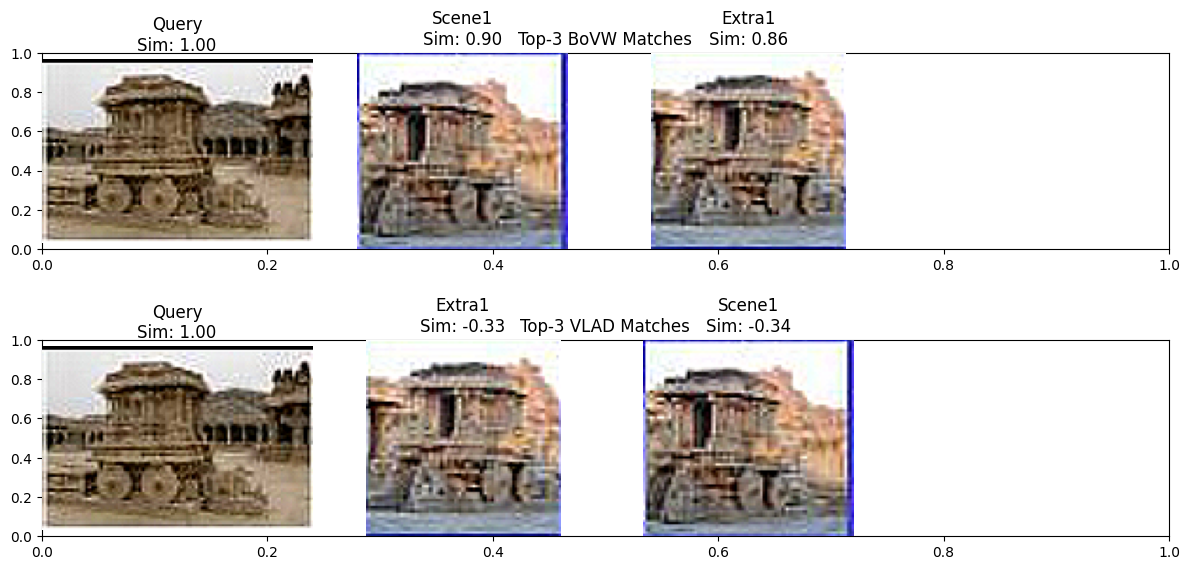

In [8]:
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.title("Top-3 BoVW Matches")
for i, idx in enumerate(bovw_matches):
    plt.subplot(2, 4, i + 1)
    plt.imshow(cv2.cvtColor(images[idx], cv2.COLOR_BGR2RGB))
    plt.title(f"{names[idx]}\nSim: {sim_bovw[idx]:.2f}")
    plt.axis('off')

plt.subplot(2, 1, 2)
plt.title("Top-3 VLAD Matches")
for i, idx in enumerate(vlad_matches):
    plt.subplot(2, 4, 4 + i + 1)
    plt.imshow(cv2.cvtColor(images[idx], cv2.COLOR_BGR2RGB))
    plt.title(f"{names[idx]}\nSim: {sim_vlad[idx]:.2f}")
    plt.axis('off')

plt.tight_layout()
plt.show()

Extension: Histogram-Based Comparison with Query

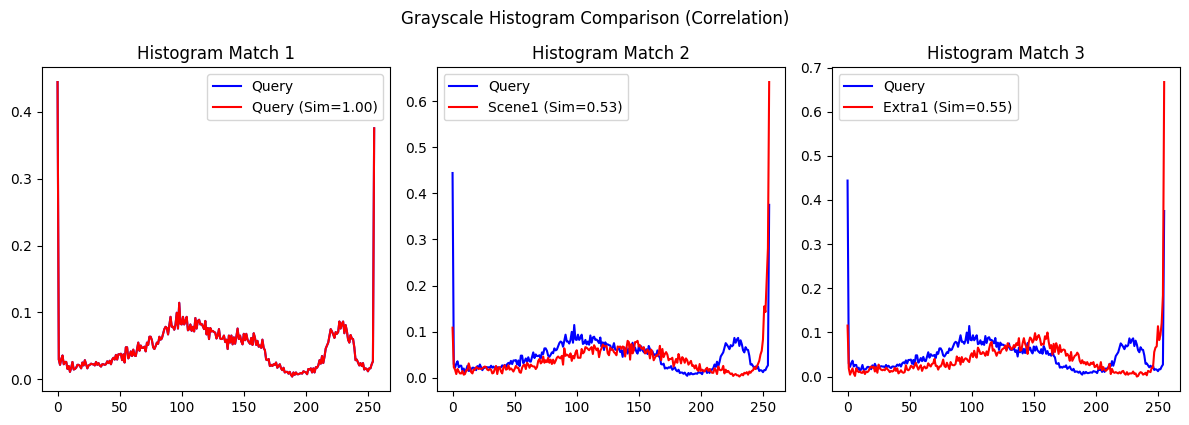

In [9]:
def compute_gray_histogram(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    hist = cv2.calcHist([gray], [0], None, [256], [0, 256])
    hist = cv2.normalize(hist, hist).flatten()
    return hist

def histogram_similarity(query_hist, other_hist):
    # Use correlation or chi-square
    return cv2.compareHist(query_hist.astype(np.float32),
                           other_hist.astype(np.float32),
                           cv2.HISTCMP_CORREL)  # or HISTCMP_CHISQR

# Compute histograms
query_hist = compute_gray_histogram(images[query_index])
top_histograms = [compute_gray_histogram(images[i]) for i in bovw_matches]

# Plot histograms of query vs matches
plt.figure(figsize=(12, 4))
for i, (idx, hist) in enumerate(zip(bovw_matches, top_histograms)):
    sim = histogram_similarity(query_hist, hist)
    plt.subplot(1, 3, i+1)
    plt.plot(query_hist, label="Query", color='blue')
    plt.plot(hist, label=f"{names[idx]} (Sim={sim:.2f})", color='red')
    plt.legend()
    plt.title(f"Histogram Match {i+1}")
plt.tight_layout()
plt.suptitle("Grayscale Histogram Comparison (Correlation)", y=1.05)
plt.show()